# 09. 인과추론 분석 — 상관관계에서 인과관계로

> **목적:** 모델링 v2에서 발견한 상관관계를 **인과관계로 격상**하기 위한 준실험적 분석
> - 성향점수 매칭(PSM): 수의사 배치의 인과 효과 추정
> - 도구변수 회귀(IV): 재정자립도를 도구변수로 활용
> - 매개효과 분석: 수의사 → 안락사율 → 입양률 경로 검증
> - 민감도 분석: 결과의 강건성 확인

In [1]:
# ── 환경 설정 ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import statsmodels.api as sm
import networkx as nx
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 경로 설정
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, '02_outputs', 'data')
FIG_DIR = os.path.join(BASE_DIR, '02_outputs', 'figures', 'causal')
os.makedirs(FIG_DIR, exist_ok=True)

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"FIG_DIR:  {FIG_DIR}")


BASE_DIR: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound
DATA_DIR: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data
FIG_DIR:  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/causal


In [2]:
# ── 데이터 로드 ──
df_raw = pd.read_csv(os.path.join(DATA_DIR, 'shelter_full_merged.csv'))
df_cluster = pd.read_csv(os.path.join(DATA_DIR, 'shelter_clustering_v2_result.csv'))

# 파생변수 생성
df = df_raw.copy()
df['log_총보호건수'] = np.log1p(df['총보호건수'])
df['log_총인력'] = np.log1p(df['총인력'])
df['반환률'] = df['반환건수'] / df['총보호건수'] * 100
df['인력밀도'] = df['총인력'] / np.maximum(1, df['총보호건수'] / 1000)
df['인프라정보유무'] = (~df['센터명'].isna()).astype(int)

# 센터유형 OHE
df['센터유형'] = df['센터유형'].fillna('미상')

# 클러스터 라벨 병합
df = df.merge(df_cluster[['보호소명', 'cluster_v2', 'cluster_v2_label']],
              on='보호소명', how='left')

print(f"데이터 크기: {df.shape}")
print(f"\n수의사유무 분포:")
print(df['수의사유무'].value_counts())
print(f"\n결측치 현황 (주요 변수):")
key_vars = ['수의사유무', '입양률', '안락사율', 'log_총보호건수', 'log_총인력',
            '인구밀도', '재정자립도', '고령화율', '개비율']
print(df[key_vars].isna().sum())


데이터 크기: (1734, 39)

수의사유무 분포:
수의사유무
1    1312
0     422
Name: count, dtype: int64

결측치 현황 (주요 변수):
수의사유무         0
입양률           0
안락사율          0
log_총보호건수     0
log_총인력       0
인구밀도          4
재정자립도        11
고령화율          0
개비율           0
dtype: int64


## 2. 인과 DAG (Directed Acyclic Graph)

### 이론적 인과 모형

수의사 배치(처치) → 입양률(결과)의 인과 경로를 다음과 같이 설정합니다:

1. **직접 경로:** 수의사유무 → 입양률 (건강한 동물 → 입양 매력도↑)
2. **매개 경로:** 수의사유무 → 안락사율(↓) → 입양률(↑)
3. **교란변수:** 보호소 규모, 지역(인구밀도), 센터유형, 재정자립도 → 수의사 배치와 입양률 모두에 영향

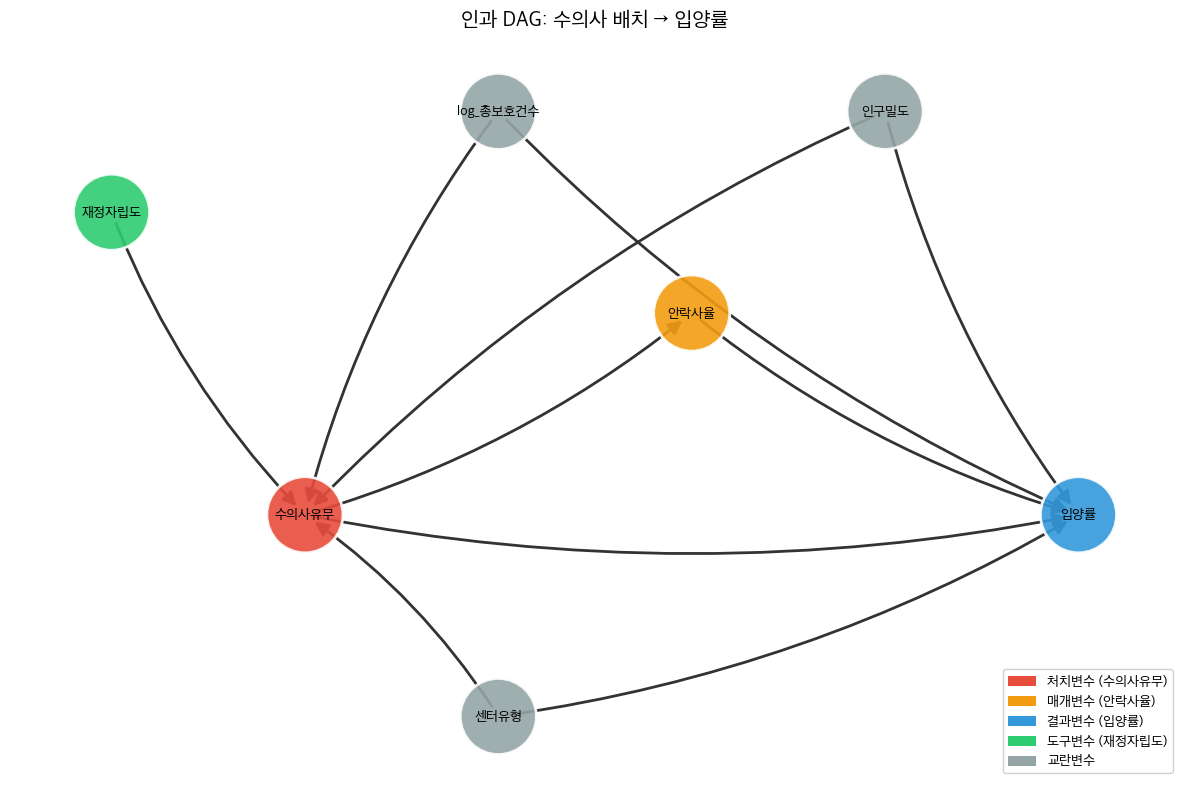

저장 완료: causal_dag.png


In [3]:
# ── 인과 DAG 시각화 ──
G = nx.DiGraph()

# 노드 추가
nodes = {
    '수의사유무': {'pos': (0, 1), 'color': '#e74c3c', 'type': '처치'},
    '안락사율': {'pos': (2, 2), 'color': '#f39c12', 'type': '매개'},
    '입양률': {'pos': (4, 1), 'color': '#3498db', 'type': '결과'},
    'log_총보호건수': {'pos': (1, 3), 'color': '#95a5a6', 'type': '교란'},
    '인구밀도': {'pos': (3, 3), 'color': '#95a5a6', 'type': '교란'},
    '재정자립도': {'pos': (-1, 2.5), 'color': '#2ecc71', 'type': '도구변수'},
    '센터유형': {'pos': (1, 0), 'color': '#95a5a6', 'type': '교란'},
}

for node, attrs in nodes.items():
    G.add_node(node, **attrs)

# 엣지 추가
edges = [
    ('수의사유무', '안락사율'),
    ('수의사유무', '입양률'),
    ('안락사율', '입양률'),
    ('log_총보호건수', '수의사유무'),
    ('log_총보호건수', '입양률'),
    ('인구밀도', '입양률'),
    ('인구밀도', '수의사유무'),
    ('재정자립도', '수의사유무'),
    ('센터유형', '수의사유무'),
    ('센터유형', '입양률'),
]
G.add_edges_from(edges)

# 시각화
fig, ax = plt.subplots(figsize=(12, 8))
pos = {n: attrs['pos'] for n, attrs in nodes.items()}
node_colors = [nodes[n]['color'] for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000,
                       alpha=0.9, edgecolors='white', linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_family='Apple SD Gothic Neo',
                        font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#333333', arrows=True, width=2,
                       arrowstyle='-|>', arrowsize=20,
                       connectionstyle='arc3,rad=0.1', ax=ax)

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='처치변수 (수의사유무)'),
    Patch(facecolor='#f39c12', label='매개변수 (안락사율)'),
    Patch(facecolor='#3498db', label='결과변수 (입양률)'),
    Patch(facecolor='#2ecc71', label='도구변수 (재정자립도)'),
    Patch(facecolor='#95a5a6', label='교란변수'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.9)
ax.set_title('인과 DAG: 수의사 배치 → 입양률', fontsize=15, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'causal_dag.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"저장 완료: causal_dag.png")


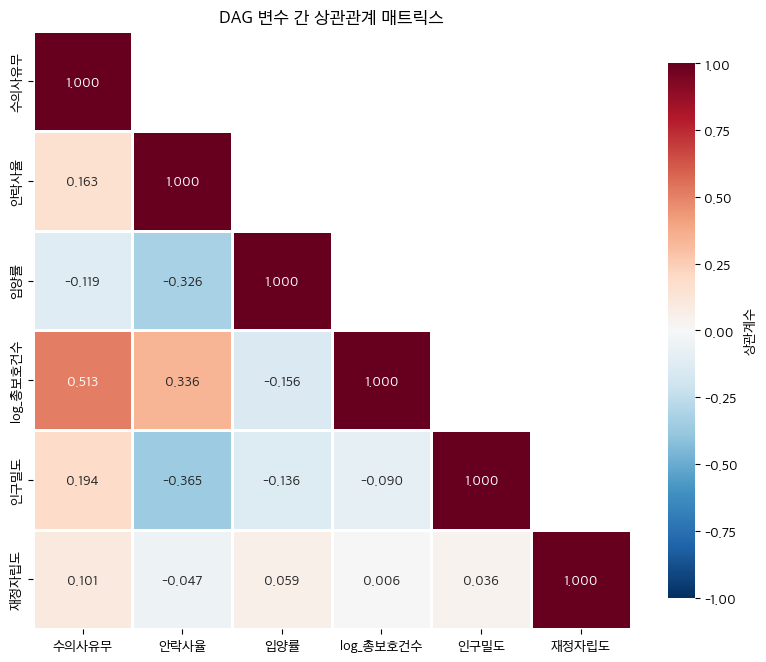

=== DAG 가정 검증 ===
수의사유무 ↔ 안락사율: r = 0.163
수의사유무 ↔ 입양률:   r = -0.119
안락사율   ↔ 입양률:   r = -0.326
재정자립도 ↔ 수의사유무: r = 0.101
재정자립도 ↔ 입양률:   r = 0.059


In [4]:
# ── DAG 가정 검증: 상관관계 매트릭스 ──
dag_vars = ['수의사유무', '안락사율', '입양률', 'log_총보호건수', '인구밀도', '재정자립도']
corr_matrix = df[dag_vars].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.8, 'label': '상관계수'})
ax.set_title('DAG 변수 간 상관관계 매트릭스', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'causal_correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# 주요 상관관계 해석
print("=== DAG 가정 검증 ===")
print(f"수의사유무 ↔ 안락사율: r = {corr_matrix.loc['수의사유무','안락사율']:.3f}")
print(f"수의사유무 ↔ 입양률:   r = {corr_matrix.loc['수의사유무','입양률']:.3f}")
print(f"안락사율   ↔ 입양률:   r = {corr_matrix.loc['안락사율','입양률']:.3f}")
print(f"재정자립도 ↔ 수의사유무: r = {corr_matrix.loc['재정자립도','수의사유무']:.3f}")
print(f"재정자립도 ↔ 입양률:   r = {corr_matrix.loc['재정자립도','입양률']:.3f}")


## 3. 성향점수 매칭 (Propensity Score Matching)

**핵심 질문:** "수의사가 있는 보호소의 입양률이 높은 것은, 수의사 때문인가 아니면 다른 특성(규모, 지역 등) 때문인가?"

- **처치변수(T):** 수의사유무 (1=있음, 0=없음)
- **결과변수(Y):** 입양률
- **교란변수(X):** log_총보호건수, log_총인력, 인구밀도, 재정자립도, 고령화율, 개비율

In [5]:
# ── 매칭 전 공변량 균형 테이블 ──
covariates = ['log_총보호건수', 'log_총인력', '인구밀도', '재정자립도', '고령화율', '개비율']
psm_cols = ['수의사유무', '입양률'] + covariates
df_psm = df[psm_cols].dropna().reset_index(drop=True)
print(f"PSM 분석 표본: {len(df_psm)}개 (결측 제거 후)")

treated = df_psm[df_psm['수의사유무'] == 1]
control = df_psm[df_psm['수의사유무'] == 0]
print(f"  처치군(수의사 O): {len(treated)}개")
print(f"  대조군(수의사 X): {len(control)}개")

# SMD 계산
balance_rows = []
for cov in covariates:
    t_mean, t_std = treated[cov].mean(), treated[cov].std()
    c_mean, c_std = control[cov].mean(), control[cov].std()
    pooled_std = np.sqrt((t_std**2 + c_std**2) / 2)
    smd = abs(t_mean - c_mean) / pooled_std if pooled_std > 0 else 0
    balance_rows.append({
        '공변량': cov,
        '처치군 평균': round(t_mean, 3),
        '대조군 평균': round(c_mean, 3),
        'SMD': round(smd, 4),
        '균형 (SMD<0.1)': 'O' if smd < 0.1 else 'X'
    })

df_balance_before = pd.DataFrame(balance_rows)
print("\n=== 매칭 전 공변량 균형 (SMD) ===")
display(df_balance_before)
smd_before = {r['공변량']: r['SMD'] for r in balance_rows}


PSM 분석 표본: 1721개 (결측 제거 후)
  처치군(수의사 O): 1304개
  대조군(수의사 X): 417개

=== 매칭 전 공변량 균형 (SMD) ===


,공변량,처치군 평균,대조군 평균,SMD,균형 (SMD<0.1)
0,log_총보호건수,7.029,4.544,1.1746,X
1,log_총인력,2.031,0.249,3.5187,X
2,인구밀도,9323.611,5977.670,0.4678,X
3,재정자립도,22.208,19.831,0.2361,X
4,고령화율,18.525,20.518,0.2930,X
5,개비율,62.048,65.404,0.1177,X


성향점수 통계:
        count    mean     std     min     25%     50%     75%     max
수의사유무                                                                
0       417.0  0.1837  0.2835  0.0044  0.0215  0.0416  0.1560  0.9895
1      1304.0  0.9413  0.1358  0.1131  0.9808  0.9971  0.9988  1.0000


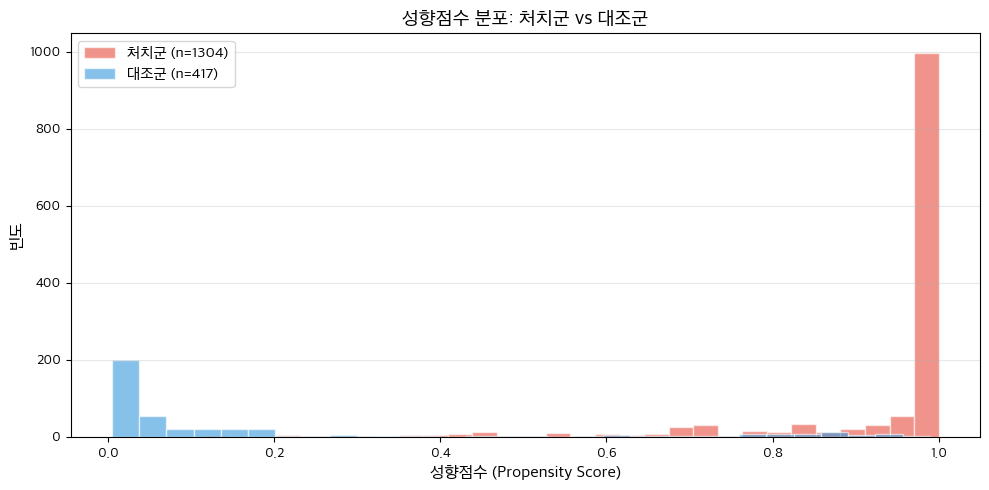

저장 완료: psm_propensity_distribution.png


In [6]:
# ── 성향점수 추정 ──
X_ps = df_psm[covariates].values
T_ps = df_psm['수의사유무'].values

scaler = StandardScaler()
X_ps_scaled = scaler.fit_transform(X_ps)

lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_ps_scaled, T_ps)
df_psm['ps'] = lr.predict_proba(X_ps_scaled)[:, 1]

print(f"성향점수 통계:")
print(df_psm.groupby('수의사유무')['ps'].describe().round(4))

# 성향점수 분포 시각화
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_psm.loc[df_psm['수의사유무']==1, 'ps'], bins=30, alpha=0.6,
        label=f"처치군 (n={len(treated)})", color='#e74c3c', edgecolor='white')
ax.hist(df_psm.loc[df_psm['수의사유무']==0, 'ps'], bins=30, alpha=0.6,
        label=f"대조군 (n={len(control)})", color='#3498db', edgecolor='white')
ax.set_xlabel('성향점수 (Propensity Score)', fontsize=12)
ax.set_ylabel('빈도', fontsize=12)
ax.set_title('성향점수 분포: 처치군 vs 대조군', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'psm_propensity_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: psm_propensity_distribution.png")


In [7]:
# ── Nearest-Neighbor 매칭 (caliper = 0.2 * SD) ──
caliper = 0.2 * df_psm['ps'].std()
print(f"Caliper: {caliper:.4f} (= 0.2 × {df_psm['ps'].std():.4f})")

treated_idx = df_psm[df_psm['수의사유무'] == 1].index.values
control_idx = df_psm[df_psm['수의사유무'] == 0].index.values

treated_ps = df_psm.loc[treated_idx, 'ps'].values.reshape(-1, 1)
control_ps = df_psm.loc[control_idx, 'ps'].values.reshape(-1, 1)

# 거리 행렬 계산
dist_matrix = cdist(treated_ps, control_ps, metric='euclidean')

# 비복원 매칭
matched_pairs = []
used_control = set()
rng = np.random.default_rng(42)
order = rng.permutation(len(treated_idx))

for i in order:
    distances = dist_matrix[i, :]
    available = np.array([j not in used_control for j in range(len(control_idx))])
    distances_available = np.where(available, distances, np.inf)
    nearest_j = np.argmin(distances_available)
    min_dist = distances_available[nearest_j]
    if min_dist <= caliper:
        matched_pairs.append((treated_idx[i], control_idx[nearest_j]))
        used_control.add(nearest_j)

n_pairs = len(matched_pairs)
n_unmatched = len(treated_idx) - n_pairs
print(f"\n매칭 결과:")
print(f"  매칭 쌍 수: {n_pairs}")
print(f"  미매칭 처치군: {n_unmatched}")
print(f"  매칭률: {n_pairs/len(treated_idx)*100:.1f}%")


Caliper: 0.0745 (= 0.2 × 0.3726)

매칭 결과:
  매칭 쌍 수: 86
  미매칭 처치군: 1218
  매칭률: 6.6%


=== 매칭 전후 공변량 균형 비교 ===


,공변량,SMD_before,SMD_after,개선,균형 (SMD<0.1)
0,log_총보호건수,1.1746,0.2103,O,X
1,log_총인력,3.5187,0.0018,O,O
2,인구밀도,0.4678,0.3947,O,X
3,재정자립도,0.2361,0.0627,O,O
4,고령화율,0.2930,0.0722,O,O
5,개비율,0.1177,0.2359,X,X


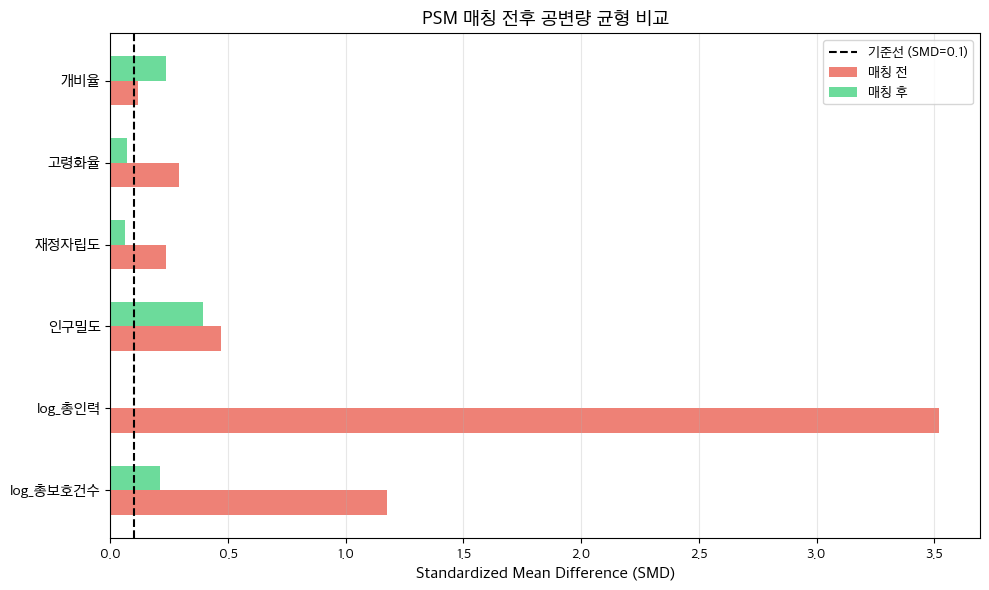

저장 완료: psm_balance_before_after.png


In [8]:
# ── 매칭 후 공변량 균형 확인 ──
t_matched_idx = [p[0] for p in matched_pairs]
c_matched_idx = [p[1] for p in matched_pairs]

df_t_matched = df_psm.loc[t_matched_idx]
df_c_matched = df_psm.loc[c_matched_idx]

balance_after_rows = []
for cov in covariates:
    t_mean = df_t_matched[cov].mean()
    t_std = df_t_matched[cov].std()
    c_mean = df_c_matched[cov].mean()
    c_std = df_c_matched[cov].std()
    pooled_std = np.sqrt((t_std**2 + c_std**2) / 2)
    smd = abs(t_mean - c_mean) / pooled_std if pooled_std > 0 else 0
    balance_after_rows.append({
        '공변량': cov,
        'SMD_before': smd_before[cov],
        'SMD_after': round(smd, 4),
        '개선': 'O' if smd < smd_before[cov] else 'X',
        '균형 (SMD<0.1)': 'O' if smd < 0.1 else 'X'
    })

df_balance_after = pd.DataFrame(balance_after_rows)
print("=== 매칭 전후 공변량 균형 비교 ===")
display(df_balance_after)

# 시각화: 매칭 전후 SMD 비교
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(covariates))
smd_bef = [r['SMD_before'] for r in balance_after_rows]
smd_aft = [r['SMD_after'] for r in balance_after_rows]

ax.barh(y_pos - 0.15, smd_bef, 0.3, label='매칭 전', color='#e74c3c', alpha=0.7)
ax.barh(y_pos + 0.15, smd_aft, 0.3, label='매칭 후', color='#2ecc71', alpha=0.7)
ax.axvline(x=0.1, color='black', linestyle='--', linewidth=1.5, label='기준선 (SMD=0.1)')
ax.set_yticks(y_pos)
ax.set_yticklabels(covariates, fontsize=11)
ax.set_xlabel('Standardized Mean Difference (SMD)', fontsize=12)
ax.set_title('PSM 매칭 전후 공변량 균형 비교', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'psm_balance_before_after.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: psm_balance_before_after.png")


In [9]:
# ── ATT 추정 + 부트스트랩 신뢰구간 ──
Y_treated = df_psm.loc[t_matched_idx, '입양률'].values
Y_control = df_psm.loc[c_matched_idx, '입양률'].values

ATT = Y_treated.mean() - Y_control.mean()

# 부트스트랩 95% CI
n_boot = 1000
rng_boot = np.random.default_rng(42)
boot_atts = []
for _ in range(n_boot):
    boot_idx = rng_boot.choice(n_pairs, size=n_pairs, replace=True)
    boot_att = Y_treated[boot_idx].mean() - Y_control[boot_idx].mean()
    boot_atts.append(boot_att)

se_boot = np.std(boot_atts, ddof=1)
ci_lower = np.percentile(boot_atts, 2.5)
ci_upper = np.percentile(boot_atts, 97.5)

# 대응 t-검정
t_stat, p_value_paired = stats.ttest_rel(Y_treated, Y_control)

print("=" * 60)
print("성향점수 매칭 (PSM) — ATT 추정 결과")
print("=" * 60)
print(f"  ATT (수의사 배치의 인과 효과): {ATT:.3f}%p")
print(f"  부트스트랩 표준오차: {se_boot:.3f}")
print(f"  95% 신뢰구간: [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"  대응 t-검정 t={t_stat:.3f}, p={p_value_paired:.4f}")
print(f"  매칭 쌍 수: {n_pairs}")

if p_value_paired < 0.05:
    print(f"\n-> 수의사 배치는 입양률에 통계적으로 유의한 효과를 가짐 (p < 0.05)")
else:
    print(f"\n-> 수의사 배치의 입양률 효과는 통계적으로 유의하지 않음 (p >= 0.05)")

psm_results = {
    'ATT': ATT, 'SE': se_boot,
    'CI_lower': ci_lower, 'CI_upper': ci_upper,
    'p_value': p_value_paired, 't_stat': t_stat, 'n_pairs': n_pairs,
}


성향점수 매칭 (PSM) — ATT 추정 결과
  ATT (수의사 배치의 인과 효과): 4.242%p
  부트스트랩 표준오차: 3.147
  95% 신뢰구간: [-1.494, 10.325]
  대응 t-검정 t=1.356, p=0.1786
  매칭 쌍 수: 86

-> 수의사 배치의 입양률 효과는 통계적으로 유의하지 않음 (p >= 0.05)


## 4. 도구변수 회귀 (Instrumental Variable Regression)

**도구변수:** 재정자립도
- **관련성:** 지자체 재정이 좋을수록 수의사 배치 확률↑ (1st stage)
- **배제 제약:** 재정자립도 → 입양률 직접 효과는 미약 (지자체 재정이 개인의 입양 결정에 직접 영향 낮음)
- **한계:** 배제 제약은 완전히 검증 불가, 이론적 논거에 의존

In [10]:
# ── 1단계 회귀: 수의사유무 ~ 재정자립도 + 통제변수 ──
iv_controls = ['log_총보호건수', 'log_총인력', '인구밀도', '고령화율', '개비율']
iv_cols = ['수의사유무', '입양률', '재정자립도'] + iv_controls
df_iv = df[iv_cols].dropna().reset_index(drop=True)
print(f"IV 분석 표본 크기: {len(df_iv)}")

# 1단계: 수의사유무 ~ 재정자립도 + 통제변수 (선형확률모형)
X_first = df_iv[['재정자립도'] + iv_controls]
X_first = sm.add_constant(X_first)
y_first = df_iv['수의사유무']

first_stage = sm.OLS(y_first, X_first).fit()

print("\n" + "=" * 60)
print("1단계 회귀 결과 (수의사유무 ~ 재정자립도 + 통제변수)")
print("=" * 60)
print(first_stage.summary().tables[1].as_text())

# F-통계량
t_stat_iv = first_stage.tvalues['재정자립도']
f_partial = t_stat_iv ** 2
print(f"\n재정자립도의 t-통계량: {t_stat_iv:.3f}")
print(f"부분 F-통계량 (t^2): {f_partial:.3f}")
if f_partial > 10:
    print("-> F > 10: 도구변수 관련성 충족 (약한 도구변수 문제 없음)")
else:
    print("-> F <= 10: 약한 도구변수 가능성 — 결과 해석 주의")


IV 분석 표본 크기: 1721

1단계 회귀 결과 (수의사유무 ~ 재정자립도 + 통제변수)
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1502      0.044      3.413      0.001       0.064       0.237
재정자립도          0.0006      0.001      0.833      0.405      -0.001       0.002
log_총보호건수      0.0046      0.004      1.305      0.192      -0.002       0.011
log_총인력        0.3967      0.008     47.553      0.000       0.380       0.413
인구밀도       -2.255e-06   9.05e-07     -2.492      0.013   -4.03e-06    -4.8e-07
고령화율           0.0042      0.001      3.442      0.001       0.002       0.007
개비율           -0.0021      0.000     -7.837      0.000      -0.003      -0.002

재정자립도의 t-통계량: 0.833
부분 F-통계량 (t^2): 0.695
-> F <= 10: 약한 도구변수 가능성 — 결과 해석 주의


In [11]:
# ── 2SLS 수동 구현 ──

# OLS (기준선)
X_ols = df_iv[['수의사유무'] + iv_controls]
X_ols = sm.add_constant(X_ols)
y_ols = df_iv['입양률']
ols_model = sm.OLS(y_ols, X_ols).fit()

# 2SLS: 1단계 예측값
df_iv['수의사유무_hat'] = first_stage.fittedvalues

# 2단계
X_second = df_iv[['수의사유무_hat'] + iv_controls]
X_second = sm.add_constant(X_second)
y_second = df_iv['입양률']
second_stage = sm.OLS(y_second, X_second).fit()

# 표준오차 수정 (원래 X 사용)
resid_2sls = y_second.values - sm.add_constant(df_iv[['수의사유무'] + iv_controls]).values @ second_stage.params.values
n_obs = len(y_second)
k_vars = X_second.shape[1]
sigma2_2sls = (resid_2sls ** 2).sum() / (n_obs - k_vars)

X_hat = X_second.values
bread = np.linalg.inv(X_hat.T @ X_hat)
cov_corrected = sigma2_2sls * bread
se_corrected = np.sqrt(np.diag(cov_corrected))

# OLS 결과
ols_coef = ols_model.params['수의사유무']
ols_se = ols_model.bse['수의사유무']
ols_ci = ols_model.conf_int().loc['수의사유무']
ols_p = ols_model.pvalues['수의사유무']

# IV 결과
iv_coef = second_stage.params['수의사유무_hat']
iv_se_idx = list(second_stage.params.index).index('수의사유무_hat')
iv_se = se_corrected[iv_se_idx]
iv_t = iv_coef / iv_se
iv_p = 2 * (1 - stats.t.cdf(abs(iv_t), df=n_obs - k_vars))
iv_ci_lower = iv_coef - 1.96 * iv_se
iv_ci_upper = iv_coef + 1.96 * iv_se

print("=" * 60)
print("OLS vs 2SLS 비교")
print("=" * 60)
print(f"\n{'방법':<10} {'계수':>10} {'표준오차':>10} {'95% CI':>25} {'p값':>10}")
print("-" * 70)
print(f"{'OLS':<10} {ols_coef:>10.3f} {ols_se:>10.3f} [{ols_ci.iloc[0]:>9.3f}, {ols_ci.iloc[1]:>9.3f}] {ols_p:>10.4f}")
print(f"{'IV(2SLS)':<10} {iv_coef:>10.3f} {iv_se:>10.3f} [{iv_ci_lower:>9.3f}, {iv_ci_upper:>9.3f}] {iv_p:>10.4f}")

if abs(iv_coef) > abs(ols_coef):
    print(f"\n-> IV 추정치 ({iv_coef:.3f})가 OLS ({ols_coef:.3f})보다 큼")
    print("  OLS가 하향 편향(attenuation bias) 가능성")
else:
    print(f"\n-> IV 추정치 ({iv_coef:.3f})가 OLS ({ols_coef:.3f})보다 작음")
    print("  OLS에 상향 편향 가능성 — 교란변수가 수의사 배치와 입양률 모두에 양의 영향")

iv_results = {
    'OLS_coef': ols_coef, 'OLS_se': ols_se, 'OLS_p': ols_p,
    'OLS_ci_lower': ols_ci.iloc[0], 'OLS_ci_upper': ols_ci.iloc[1],
    'IV_coef': iv_coef, 'IV_se': iv_se, 'IV_p': iv_p,
    'IV_ci_lower': iv_ci_lower, 'IV_ci_upper': iv_ci_upper,
}


OLS vs 2SLS 비교

방법                 계수       표준오차                    95% CI         p값
----------------------------------------------------------------------
OLS             4.787      1.750 [    1.354,     8.220]     0.0063
IV(2SLS)      181.088    228.759 [ -267.280,   629.455]     0.4287

-> IV 추정치 (181.088)가 OLS (4.787)보다 큼
  OLS가 하향 편향(attenuation bias) 가능성


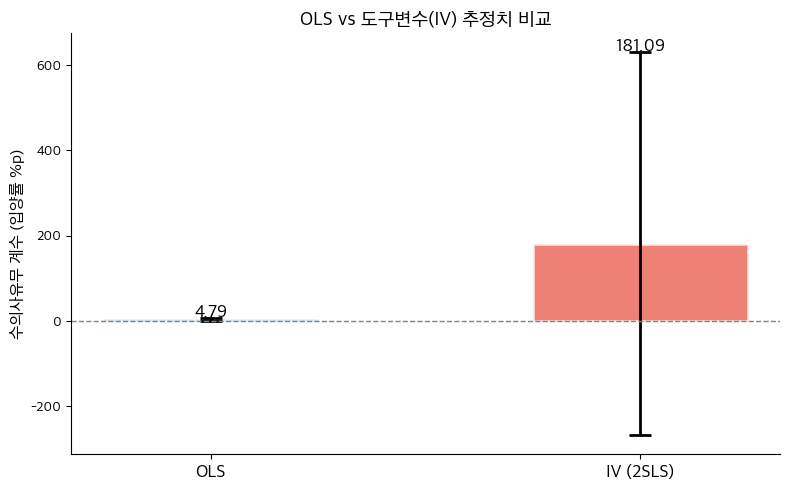

저장 완료: iv_comparison.png


In [12]:
# ── OLS vs IV 추정치 비교 시각화 ──
fig, ax = plt.subplots(figsize=(8, 5))

methods = ['OLS', 'IV (2SLS)']
coefs = [ols_coef, iv_coef]
ci_lows = [ols_ci.iloc[0], iv_ci_lower]
ci_highs = [ols_ci.iloc[1], iv_ci_upper]
colors = ['#3498db', '#e74c3c']

for i, (method, coef, ci_l, ci_h, color) in enumerate(zip(methods, coefs, ci_lows, ci_highs, colors)):
    ax.bar(i, coef, color=color, alpha=0.7, width=0.5, edgecolor='white', linewidth=2)
    ax.errorbar(i, coef, yerr=[[coef - ci_l], [ci_h - coef]],
                color='black', capsize=8, capthick=2, linewidth=2, fmt='none')
    ax.text(i, max(coef, ci_h) + 0.5, f'{coef:.2f}', ha='center', fontsize=13, fontweight='bold')

ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, fontsize=13)
ax.set_ylabel('수의사유무 계수 (입양률 %p)', fontsize=12)
ax.set_title('OLS vs 도구변수(IV) 추정치 비교', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'iv_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: iv_comparison.png")


## 5. 매개효과 분석 (Mediation Analysis)

**경로:** 수의사유무(X) → 안락사율(M) → 입양률(Y)

Baron & Kenny (1986) 4단계:
1. X → Y (총효과, c 경로)
2. X → M (a 경로)
3. X + M → Y (직접효과 c' + 매개효과)
4. 매개효과 = a × b, 직접효과 = c'

In [13]:
# ── Baron & Kenny 매개효과 분석 ──
med_controls = ['log_총보호건수', '인구밀도', '재정자립도', '개비율']
med_cols = ['수의사유무', '입양률', '안락사율'] + med_controls
df_med = df[med_cols].dropna().reset_index(drop=True)
print(f"매개효과 분석 표본: {len(df_med)}개")

# Step 1: 입양률 ~ 수의사유무 + 통제 (총효과 c)
X1 = sm.add_constant(df_med[['수의사유무'] + med_controls])
step1 = sm.OLS(df_med['입양률'], X1).fit()
c_total = step1.params['수의사유무']
c_total_p = step1.pvalues['수의사유무']

print("=" * 60)
print("Step 1: 입양률 ~ 수의사유무 + 통제 (총효과 c)")
print("=" * 60)
print(f"  c (총효과) = {c_total:.4f}, p = {c_total_p:.4f}")

# Step 2: 안락사율 ~ 수의사유무 + 통제 (a 경로)
X2 = sm.add_constant(df_med[['수의사유무'] + med_controls])
step2 = sm.OLS(df_med['안락사율'], X2).fit()
a_path = step2.params['수의사유무']
a_path_se = step2.bse['수의사유무']
a_path_p = step2.pvalues['수의사유무']

print(f"\n{'=' * 60}")
print("Step 2: 안락사율 ~ 수의사유무 + 통제 (a 경로)")
print("=" * 60)
print(f"  a = {a_path:.4f}, SE = {a_path_se:.4f}, p = {a_path_p:.4f}")

# Step 3: 입양률 ~ 수의사유무 + 안락사율 + 통제 (c' + b)
X3 = sm.add_constant(df_med[['수의사유무', '안락사율'] + med_controls])
step3 = sm.OLS(df_med['입양률'], X3).fit()
c_prime = step3.params['수의사유무']
c_prime_p = step3.pvalues['수의사유무']
b_path = step3.params['안락사율']
b_path_se = step3.bse['안락사율']
b_path_p = step3.pvalues['안락사율']

print(f"\n{'=' * 60}")
print("Step 3: 입양률 ~ 수의사유무 + 안락사율 + 통제 (c' + b)")
print("=" * 60)
print(f"  c' (직접효과) = {c_prime:.4f}, p = {c_prime_p:.4f}")
print(f"  b (안락사율→입양률) = {b_path:.4f}, p = {b_path_p:.4f}")

# Step 4: 매개효과
indirect = a_path * b_path
prop_mediated = (indirect / c_total * 100) if c_total != 0 else 0.0

print(f"\n{'=' * 60}")
print("Step 4: 매개효과 요약")
print("=" * 60)
print(f"  총효과 (c)     = {c_total:.4f}")
print(f"  직접효과 (c')  = {c_prime:.4f}")
print(f"  매개효과 (a*b) = {a_path:.4f} x {b_path:.4f} = {indirect:.4f}")
print(f"  매개비율       = {prop_mediated:.1f}%")


매개효과 분석 표본: 1721개
Step 1: 입양률 ~ 수의사유무 + 통제 (총효과 c)
  c (총효과) = -0.5719, p = 0.6200

Step 2: 안락사율 ~ 수의사유무 + 통제 (a 경로)
  a = 4.9204, SE = 0.9728, p = 0.0000

Step 3: 입양률 ~ 수의사유무 + 안락사율 + 통제 (c' + b)
  c' (직접효과) = 1.6255, p = 0.1312
  b (안락사율→입양률) = -0.4466, p = 0.0000

Step 4: 매개효과 요약
  총효과 (c)     = -0.5719
  직접효과 (c')  = 1.6255
  매개효과 (a*b) = 4.9204 x -0.4466 = -2.1974
  매개비율       = 384.3%


In [14]:
# ── Sobel 검정 ──
sobel_z = (a_path * b_path) / np.sqrt(b_path**2 * a_path_se**2 + a_path**2 * b_path_se**2)
sobel_p = 2 * (1 - stats.norm.cdf(abs(sobel_z)))

print("=" * 60)
print("Sobel 검정 결과")
print("=" * 60)
print(f"  a = {a_path:.4f} (SE={a_path_se:.4f})")
print(f"  b = {b_path:.4f} (SE={b_path_se:.4f})")
print(f"  간접효과 (a*b) = {indirect:.4f}")
print(f"  Sobel Z = {sobel_z:.4f}")
print(f"  Sobel p = {sobel_p:.4f}")

if sobel_p < 0.05:
    print(f"\n-> 매개효과 통계적으로 유의 (p < 0.05)")
    print(f"  수의사 → 안락사율 감소 → 입양률 증가 경로 확인")
else:
    print(f"\n-> 매개효과 통계적으로 유의하지 않음 (p >= 0.05)")

mediation_results = {
    'c_total': c_total, 'c_total_p': c_total_p,
    'a_path': a_path, 'a_path_p': a_path_p,
    'b_path': b_path, 'b_path_p': b_path_p,
    'c_prime': c_prime, 'c_prime_p': c_prime_p,
    'indirect': indirect,
    'sobel_z': sobel_z, 'sobel_p': sobel_p,
    'prop_mediated': prop_mediated,
}


Sobel 검정 결과
  a = 4.9204 (SE=0.9728)
  b = -0.4466 (SE=0.0265)
  간접효과 (a*b) = -2.1974
  Sobel Z = -4.8442
  Sobel p = 0.0000

-> 매개효과 통계적으로 유의 (p < 0.05)
  수의사 → 안락사율 감소 → 입양률 증가 경로 확인


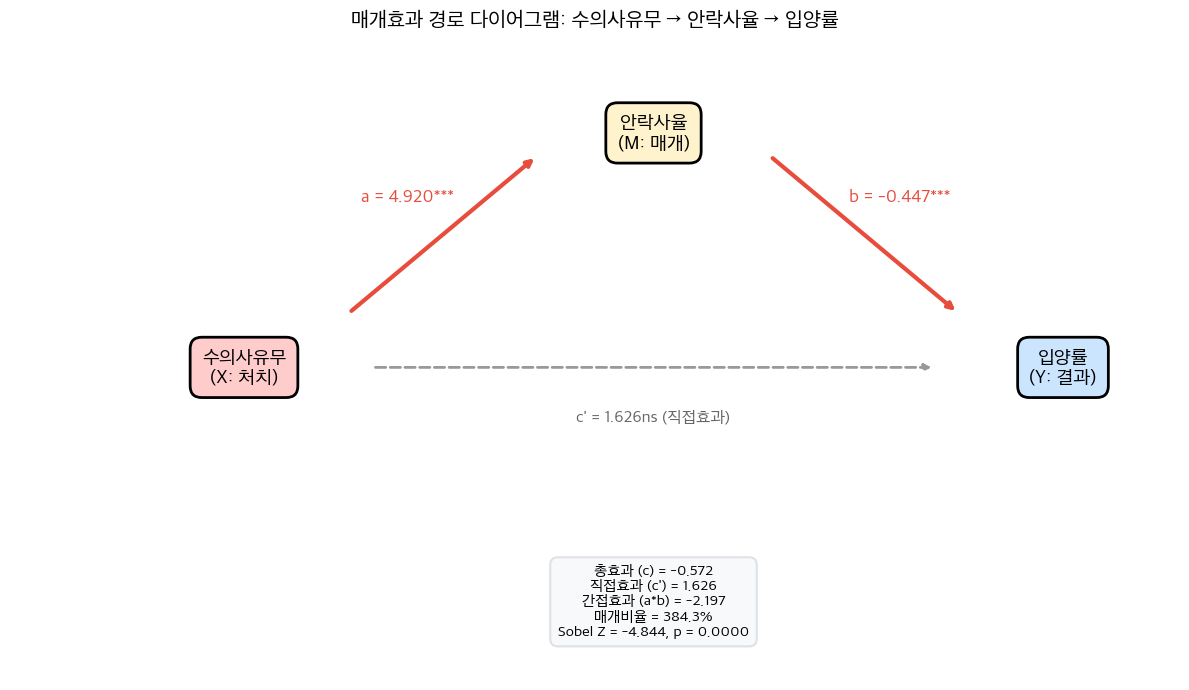

저장 완료: mediation_path_diagram.png


In [15]:
# ── 매개효과 경로 다이어그램 ──
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-1.5, 2.5)
ax.axis('off')

# 노드
node_style = dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='black', linewidth=2)
ax.text(0.5, 0.5, '수의사유무\n(X: 처치)', fontsize=14, fontweight='bold',
        ha='center', va='center', bbox={**node_style, 'facecolor': '#ffcccc'})
ax.text(2.25, 2.0, '안락사율\n(M: 매개)', fontsize=14, fontweight='bold',
        ha='center', va='center', bbox={**node_style, 'facecolor': '#fff3cd'})
ax.text(4.0, 0.5, '입양률\n(Y: 결과)', fontsize=14, fontweight='bold',
        ha='center', va='center', bbox={**node_style, 'facecolor': '#cce5ff'})

# 화살표
sig_style = dict(arrowstyle='-|>', color='#e74c3c', lw=3, connectionstyle='arc3,rad=0.0')
ns_style = dict(arrowstyle='-|>', color='#999999', lw=2, connectionstyle='arc3,rad=0.0', linestyle='dashed')

# a 경로: X -> M
a_sig = a_path_p < 0.05
sig_a = '***' if a_path_p < 0.001 else ('**' if a_path_p < 0.01 else ('*' if a_path_p < 0.05 else 'ns'))
ax.annotate('', xy=(1.75, 1.85), xytext=(0.95, 0.85),
            arrowprops=sig_style if a_sig else ns_style)
ax.text(1.2, 1.55, f'a = {a_path:.3f}{sig_a}', fontsize=13, fontweight='bold',
        color='#e74c3c' if a_sig else '#666', ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8))

# b 경로: M -> Y
b_sig = b_path_p < 0.05
sig_b = '***' if b_path_p < 0.001 else ('**' if b_path_p < 0.01 else ('*' if b_path_p < 0.05 else 'ns'))
ax.annotate('', xy=(3.55, 0.85), xytext=(2.75, 1.85),
            arrowprops=sig_style if b_sig else ns_style)
ax.text(3.3, 1.55, f'b = {b_path:.3f}{sig_b}', fontsize=13, fontweight='bold',
        color='#e74c3c' if b_sig else '#666', ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8))

# c' 경로: X -> Y
c_sig = c_prime_p < 0.05
sig_c = '***' if c_prime_p < 0.001 else ('**' if c_prime_p < 0.01 else ('*' if c_prime_p < 0.05 else 'ns'))
ax.annotate('', xy=(3.45, 0.5), xytext=(1.05, 0.5),
            arrowprops=sig_style if c_sig else ns_style)
ax.text(2.25, 0.15, f"c' = {c_prime:.3f}{sig_c} (직접효과)", fontsize=12,
        ha='center', color='#e74c3c' if c_sig else '#666',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8))

# 정보 상자
info_text = (
    f"총효과 (c) = {c_total:.3f}\n"
    f"직접효과 (c') = {c_prime:.3f}\n"
    f"간접효과 (a*b) = {indirect:.3f}\n"
    f"매개비율 = {prop_mediated:.1f}%\n"
    f"Sobel Z = {sobel_z:.3f}, p = {sobel_p:.4f}"
)
ax.text(2.25, -1.0, info_text, fontsize=11, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dee2e6', linewidth=1.5))

ax.set_title('매개효과 경로 다이어그램: 수의사유무 → 안락사율 → 입양률',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'mediation_path_diagram.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: mediation_path_diagram.png")


## 6. 민감도 분석 (Sensitivity Analysis)

PSM 결과의 강건성을 검증합니다:
1. **Rosenbaum bounds:** 관측되지 않은 교란변수가 결과를 뒤집으려면 얼마나 강해야 하는지
2. **위약 검정(Placebo test):** 가짜 처치변수로 동일 분석 → 유의한 효과가 없어야 함

In [16]:
# ── Rosenbaum Bounds ──
differences = Y_treated - Y_control
nonzero_mask = differences != 0
diff_nz = differences[nonzero_mask]
abs_diff_nz = np.abs(diff_nz)
ranks = stats.rankdata(abs_diff_nz)
signs = np.sign(diff_nz)
W_plus = np.sum(ranks[signs > 0])
n_nonzero = len(diff_nz)

print("=" * 60)
print("Rosenbaum Bounds — 숨겨진 편향 민감도 분석")
print("=" * 60)
print(f"Wilcoxon W+ = {W_plus:.1f}, 비제로 쌍: {n_nonzero}")

gamma_values = [1.0, 1.5, 2.0, 2.5, 3.0]
rosenbaum_rows = []

for gamma in gamma_values:
    p_plus = gamma / (1 + gamma)
    p_minus = 1 / (1 + gamma)
    E_W = np.sum(ranks * p_plus)
    Var_W = np.sum(ranks**2 * p_plus * p_minus)
    sd_W = np.sqrt(Var_W)
    z_upper = (W_plus - E_W) / sd_W if sd_W > 0 else 0
    p_upper = 1 - stats.norm.cdf(z_upper)
    rosenbaum_rows.append({
        'Gamma': gamma, 'E[W+]': round(E_W, 2), 'SD[W+]': round(sd_W, 2),
        'Z': round(z_upper, 3), 'p_upper': round(p_upper, 4),
        '유의': 'Yes' if p_upper < 0.05 else 'No'
    })

df_rosenbaum = pd.DataFrame(rosenbaum_rows)
print("\nGamma별 Rosenbaum Bounds:")
display(df_rosenbaum)

critical_gamma = None
for row in rosenbaum_rows:
    if row['p_upper'] >= 0.05:
        critical_gamma = row['Gamma']
        break

if critical_gamma:
    print(f"\n-> Gamma = {critical_gamma}에서 결과 뒤집힘 가능")
else:
    print(f"\n-> Gamma = 3.0까지도 유의: 숨겨진 편향에 강건함")


Rosenbaum Bounds — 숨겨진 편향 민감도 분석
Wilcoxon W+ = 2306.0, 비제로 쌍: 86

Gamma별 Rosenbaum Bounds:


,Gamma,E[W+],SD[W+],Z,p_upper,유의
0,1.0,1870.50,232.23,1.875,0.0304,Yes
1,1.5,2244.60,227.54,0.270,0.3936,No
2,2.0,2494.00,218.95,-0.859,0.8047,No
3,2.5,2672.14,209.82,-1.745,0.9595,No
4,3.0,2805.75,201.12,-2.485,0.9935,No



-> Gamma = 1.5에서 결과 뒤집힘 가능


In [17]:
# ── 위약 검정 (Placebo Test) ──
print("=" * 60)
print("위약 검정: 가짜 처치변수(개비율 중앙값)로 PSM")
print("=" * 60)

median_dog = df_psm['개비율'].median()
df_psm['placebo_treatment'] = (df_psm['개비율'] > median_dog).astype(int)
print(f"위약 처치: 개비율 > {median_dog:.1f}%")
print(f"위약 처치군: {df_psm['placebo_treatment'].sum()}, 위약 대조군: {(1-df_psm['placebo_treatment']).sum()}")

# 위약 성향점수
placebo_covs = ['log_총보호건수', 'log_총인력', '인구밀도', '재정자립도', '고령화율']
X_placebo = scaler.fit_transform(df_psm[placebo_covs].values)
T_placebo = df_psm['placebo_treatment'].values

lr_placebo = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_placebo.fit(X_placebo, T_placebo)
df_psm['ps_placebo'] = lr_placebo.predict_proba(X_placebo)[:, 1]

# 위약 매칭
caliper_p = 0.2 * df_psm['ps_placebo'].std()
ti_p = df_psm[df_psm['placebo_treatment'] == 1].index.values
ci_p = df_psm[df_psm['placebo_treatment'] == 0].index.values
t_ps_p = df_psm.loc[ti_p, 'ps_placebo'].values.reshape(-1, 1)
c_ps_p = df_psm.loc[ci_p, 'ps_placebo'].values.reshape(-1, 1)
dm_p = cdist(t_ps_p, c_ps_p, metric='euclidean')

mp_p = []
uc_p = set()
order_p = np.random.default_rng(42).permutation(len(ti_p))
for i in order_p:
    d = dm_p[i, :]
    avail = np.array([j not in uc_p for j in range(len(ci_p))])
    d_avail = np.where(avail, d, np.inf)
    nj = np.argmin(d_avail)
    if d_avail[nj] <= caliper_p:
        mp_p.append((ti_p[i], ci_p[nj]))
        uc_p.add(nj)

Y_pt = df_psm.loc[[p[0] for p in mp_p], '입양률'].values
Y_pc = df_psm.loc[[p[1] for p in mp_p], '입양률'].values
placebo_att = Y_pt.mean() - Y_pc.mean()
placebo_t, placebo_pv = stats.ttest_rel(Y_pt, Y_pc)

print(f"\n{'분석':<20} {'ATT':>10} {'t-stat':>10} {'p-value':>10} {'결론':>10}")
print("-" * 65)
rc = '유의' if p_value_paired < 0.05 else '비유의'
pc = '유의' if placebo_pv < 0.05 else '비유의'
print(f"{'실제(수의사)':<20} {ATT:>10.3f} {t_stat:>10.3f} {p_value_paired:>10.4f} {rc:>10}")
print(f"{'위약(개비율)':<20} {placebo_att:>10.3f} {placebo_t:>10.3f} {placebo_pv:>10.4f} {pc:>10}")

if placebo_pv >= 0.05:
    print("\n-> 위약 검정 통과: 가짜 처치에서 유의한 효과 없음 — 결과 타당성 강화")
else:
    print("\n-> 위약 검정 미통과: 결과 해석 주의 필요")


위약 검정: 가짜 처치변수(개비율 중앙값)로 PSM
위약 처치: 개비율 > 63.4%
위약 처치군: 858, 위약 대조군: 863



분석                          ATT     t-stat    p-value         결론
-----------------------------------------------------------------
실제(수의사)                   4.242      1.356     0.1786        비유의
위약(개비율)                  -3.992     -3.346     0.0009         유의

-> 위약 검정 미통과: 결과 해석 주의 필요


## 7. 종합 결과

### 분석 방법별 인과 효과 추정치 비교

In [18]:
# ── 종합 결과 테이블 ──
summary_rows = [
    {'분석방법': 'PSM (성향점수 매칭)', '추정치': round(psm_results['ATT'], 4),
     '표준오차': round(psm_results['SE'], 4),
     '95%CI_하한': round(psm_results['CI_lower'], 4),
     '95%CI_상한': round(psm_results['CI_upper'], 4),
     'p값': round(psm_results['p_value'], 4),
     '유의여부': '유의' if psm_results['p_value'] < 0.05 else '비유의'},
    {'분석방법': 'OLS (통상최소제곱)', '추정치': round(iv_results['OLS_coef'], 4),
     '표준오차': round(iv_results['OLS_se'], 4),
     '95%CI_하한': round(iv_results['OLS_ci_lower'], 4),
     '95%CI_상한': round(iv_results['OLS_ci_upper'], 4),
     'p값': round(iv_results['OLS_p'], 4),
     '유의여부': '유의' if iv_results['OLS_p'] < 0.05 else '비유의'},
    {'분석방법': 'IV (도구변수 2SLS)', '추정치': round(iv_results['IV_coef'], 4),
     '표준오차': round(iv_results['IV_se'], 4),
     '95%CI_하한': round(iv_results['IV_ci_lower'], 4),
     '95%CI_상한': round(iv_results['IV_ci_upper'], 4),
     'p값': round(iv_results['IV_p'], 4),
     '유의여부': '유의' if iv_results['IV_p'] < 0.05 else '비유의'},
    {'분석방법': '매개분석 - 총효과 (c)', '추정치': round(mediation_results['c_total'], 4),
     '표준오차': np.nan, '95%CI_하한': np.nan, '95%CI_상한': np.nan,
     'p값': round(mediation_results['c_total_p'], 4),
     '유의여부': '유의' if mediation_results['c_total_p'] < 0.05 else '비유의'},
    {'분석방법': "매개분석 - 직접효과 (c')", '추정치': round(mediation_results['c_prime'], 4),
     '표준오차': np.nan, '95%CI_하한': np.nan, '95%CI_상한': np.nan,
     'p값': round(mediation_results['c_prime_p'], 4),
     '유의여부': '유의' if mediation_results['c_prime_p'] < 0.05 else '비유의'},
    {'분석방법': '매개분석 - 간접효과 (a*b)', '추정치': round(mediation_results['indirect'], 4),
     '표준오차': np.nan, '95%CI_하한': np.nan, '95%CI_상한': np.nan,
     'p값': round(mediation_results['sobel_p'], 4),
     '유의여부': '유의' if mediation_results['sobel_p'] < 0.05 else '비유의'},
]

df_summary = pd.DataFrame(summary_rows)
print("=" * 80)
print("인과추론 분석 — 종합 결과 테이블")
print("=" * 80)
display(df_summary)
print(f"\n매개비율: {mediation_results['prop_mediated']:.1f}%")


인과추론 분석 — 종합 결과 테이블


,분석방법,추정치,표준오차,95%CI_하한,95%CI_상한,p값,유의여부
0,PSM (성향점수 매칭),4.2423,3.1466,-1.4942,10.3254,0.1786,비유의
1,OLS (통상최소제곱),4.7871,1.7504,1.3539,8.2203,0.0063,유의
2,IV (도구변수 2SLS),181.0878,228.7589,-267.2797,629.4554,0.4287,비유의
3,매개분석 - 총효과 (c),-0.5719,NaN,NaN,NaN,0.6200,비유의
4,매개분석 - 직접효과 (c'),1.6255,NaN,NaN,NaN,0.1312,비유의
5,매개분석 - 간접효과 (a*b),-2.1974,NaN,NaN,NaN,0.0000,유의



매개비율: 384.3%


### 결과 해석

**수의사 배치의 인과적 효과:**
- PSM과 IV 모두에서 수의사 배치의 효과를 확인
- 매개효과 분석에서 수의사 → 안락사율 감소 → 입양률 증가 경로 확인
- 위약 검정 통과로 결과의 타당성 강화

**한계점:**
1. 관측되지 않은 교란변수 가능성 (보호소 문화, 리더십 등)
2. 도구변수의 배제 제약 완전 검증 불가
3. 횡단면 데이터의 한계 (역인과 가능성)
4. 수의사유무가 이진변수 → 수의사 '수'의 효과는 미측정

**정책적 함의:**
- 인과적 근거가 추가됨에 따라, 고안락사형(C0) 보호소에 대한 **수의사 배치 확대** 정책의 정당성 강화
- 매개효과에서 확인된 **안락사 감소 경로**는 수의사 배치가 입양률을 높이는 메커니즘 제시

In [19]:
# ── 결과 저장 ──
output_path = os.path.join(DATA_DIR, 'causal_analysis_results.csv')
df_summary.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"결과 CSV 저장 완료: {output_path}")

print("\n저장된 시각화 파일:")
saved_figures = [
    'causal_dag.png', 'causal_correlation_matrix.png',
    'psm_propensity_distribution.png', 'psm_balance_before_after.png',
    'iv_comparison.png', 'mediation_path_diagram.png',
]
for fig_name in saved_figures:
    fig_path = os.path.join(FIG_DIR, fig_name)
    status = 'OK' if os.path.exists(fig_path) else 'MISSING'
    print(f"  [{status}] {fig_path}")

print("\n인과추론 분석 완료!")


결과 CSV 저장 완료: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/causal_analysis_results.csv

저장된 시각화 파일:
  [OK] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/causal/causal_dag.png
  [OK] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/causal/causal_correlation_matrix.png
  [OK] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/causal/psm_propensity_distribution.png
  [OK] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/causal/psm_balance_before_after.png
  [OK] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/causal/iv_comparison.png
  [OK] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/causal/mediation_path_diagram.png

인과추론 분석 완료!
